In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
#df_act_pred_gene_protein=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/df_act_pred_gene_protein_corr_OV_cancer.csv",index_col='Unnamed: 0')
df_act_pred_gene_protein=pd.read_csv("/data/kumarr17/TxCyto/results/df_act_pred_gene_protein_corr_OV_cancer.csv",index_col='Unnamed: 0')

### Figure 2E

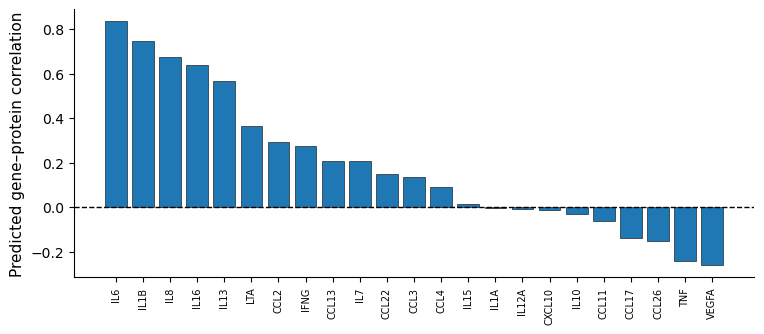

In [4]:
df=df_act_pred_gene_protein
# Sort by predicted gene-protein correlation
df_sorted = df.sort_values(
    "pred_gene_protein",
    ascending=False
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))

# Bar plot
ax.bar(
    df_sorted.index.astype(str),
    df_sorted["pred_gene_protein"],
    edgecolor="black",
    linewidth=0.4
)

# Reference line at zero
ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Axis labels
ax.set_xlabel("")

ax.set_ylabel(
    "Predicted gene–protein correlation",
    fontsize=11
)

# X-axis formatting
ax.tick_params(
    axis="x",
    rotation=90,
    labelsize=7
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No grid
ax.grid(False)

# Give extra room for gene labels
fig.subplots_adjust(
    left=0.13,
    right=0.98,
    top=0.97,
    bottom=0.30
)

# Save as vector SVG
#fig.savefig(
#    "/data/kumarr17/figures_to_upload/Figure2/Predicted_gene_protein_correlation.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()

### Figure 2F

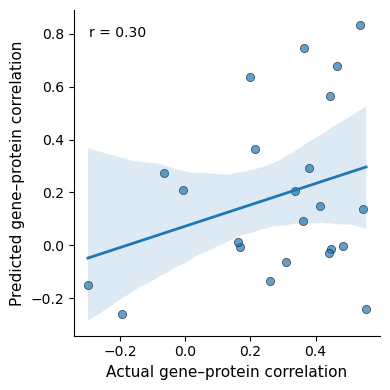

Pearson r = 0.298
P-value = 0.1677


In [5]:
# Data
x = df["act_gene_protein"]
y = df["pred_gene_protein"]

# Pearson correlation
r, p = pearsonr(x, y)

# Create figure
fig, ax = plt.subplots(figsize=(4, 4))

# Regression plot
sns.regplot(
    x=x,
    y=y,
    ax=ax,
    scatter_kws={
        "s": 35,
        "alpha": 0.7,
        "edgecolor": "black",
        "linewidth": 0.5
    },
    line_kws={
        "linewidth": 2
    }
)

# Axis labels
ax.set_xlabel(
    "Actual gene–protein correlation",
    fontsize=11
)

ax.set_ylabel(
    "Predicted gene–protein correlation",
    fontsize=11
)

# Correlation annotation
ax.text(
    0.05,
    0.95,
    f"r = {r:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# Figure formatting
ax.tick_params(axis="both", labelsize=10)

sns.despine(ax=ax)

ax.grid(False)

plt.tight_layout()

# Save as vector SVG
#fig.savefig(
#    "/data/kumarr17/figures_to_upload/Figure2/Actual_vs_predicted_gene_protein_correlation.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()

print(f"Pearson r = {r:.3f}")
print(f"P-value = {p:.4g}")